# Traffic Sign Robust Ensemble — 수동 오류 분석 반영 개선판

이 노트북은 기존 두 모델을 그대로 반복 학습하는 대신 다음을 수행합니다.

- 기존 **EfficientNet-B0 128px(A)** 및 **ConvNeXt-Tiny 192px(B)** 체크포인트 재사용
- 새로운 **Swin-T 224px(C)** 모델 추가
- 수동 검토에서 많이 발견된 `저화질·장애물·낙서·흔들림·그림자·빛반사`를 모사하는 증강 적용
- 깨끗한 validation이 이미 포화된 문제를 피하기 위해 **인위적으로 열화시킨 robust validation suite** 생성
- 테스트 수동 라벨을 직접 학습하거나 정확한 앙상블 가중치 튜닝에 사용하지 않고, robust validation에서 A/B/C 가중치를 자동 선택
- 최종 개선 앙상블 제출 파일과 비교·검토 CSV 생성

수동 검토 표본에서 실제 클래스를 확정한 55장 기준으로 A는 17장, B는 32장, 기존 50:50 앙상블은 32장을 맞혔습니다. B만 맞힌 사례가 25장이었고 그중 9장은 A의 높은 오답 확률 때문에 기존 앙상블도 틀렸습니다. 따라서 A를 무조건 50% 반영하지 않고 robust validation 결과로 비중을 정합니다.


In [1]:
from pathlib import Path
import os
import random
import zipfile
import time
import shutil
import ssl
import io
import json
import copy
import math
import unicodedata

import certifi
import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageDraw, ImageOps

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, log_loss

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import efficientnet_b0, convnext_tiny, swin_t

try:
    from torchvision.models import (
        EfficientNet_B0_Weights,
        ConvNeXt_Tiny_Weights,
        Swin_T_Weights,
    )
except ImportError as exc:
    raise ImportError(
        'EfficientNet-B0, ConvNeXt-Tiny, Swin-T를 지원하는 torchvision이 필요합니다. '
        'Colab 런타임을 재시작한 뒤 다시 실행하세요.'
    ) from exc

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())


PyTorch: 2.11.0+cu128
CUDA available: True


In [2]:
# 재현성과 A100 설정
SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed()

if not torch.cuda.is_available():
    raise RuntimeError('CUDA GPU가 필요합니다. Colab 런타임을 A100 GPU로 설정하세요.')

DEVICE = torch.device('cuda')
props = torch.cuda.get_device_properties(0)
print(f'Device: {props.name} | VRAM: {props.total_memory / 2**30:.1f} GB | CUDA: {torch.version.cuda}')

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


Device: NVIDIA A100-SXM4-40GB | VRAM: 39.5 GB | CUDA: 12.8


## 1. Drive는 저장용, `/content`는 학습용

ZIP을 Drive에서 `/content`로 한 번 복사한 뒤 압축을 풀고, 학습 중 이미지 접근은 Colab 로컬 디스크에서만 수행합니다.


In [3]:
from google.colab import drive

drive.mount('/content/drive')


def normalized_name(text):
    return unicodedata.normalize('NFC', str(text))


def resolve_normalized_path(base, parts):
    current = Path(base)
    for wanted in parts:
        if not current.is_dir():
            raise FileNotFoundError(f'상위 폴더가 없습니다: {current}')
        matches = [
            child for child in current.iterdir()
            if normalized_name(child.name) == normalized_name(wanted)
        ]
        if not matches:
            available = [child.name for child in current.iterdir() if child.is_dir()][:30]
            raise FileNotFoundError(
                f'폴더를 찾지 못했습니다: {wanted}\n현재 위치: {current}\n'
                f'확인 가능한 폴더 일부: {available}'
            )
        current = matches[0]
    return current.resolve()


DRIVE_PROJECT_ROOT = resolve_normalized_path(
    '/content/drive/MyDrive',
    ['Data scientist', '팀프로젝트', '1주차'],
)

RUNTIME_ROOT = Path('/content/traffic_sign_improved')
LOCAL_ARCHIVE = RUNTIME_ROOT / 'dataset.zip'
LOCAL_EXTRACT_ROOT = RUNTIME_ROOT / 'dataset_extracted'
LOCAL_CHECKPOINT_DIR = RUNTIME_ROOT / 'checkpoints'
LOCAL_TORCH_CACHE = RUNTIME_ROOT / 'torch_cache'

OUTPUT_DIR = DRIVE_PROJECT_ROOT / 'improved_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_TORCH_CACHE.mkdir(parents=True, exist_ok=True)

archive_candidates = [
    DRIVE_PROJECT_ROOT / 'dataset.zip',
    DRIVE_PROJECT_ROOT / 'data.zip',
]
DRIVE_ARCHIVE = next((p for p in archive_candidates if p.is_file()), None)

result_template_candidates = [
    DRIVE_PROJECT_ROOT / 'result_template_before_prediction.csv',
    DRIVE_PROJECT_ROOT / 'result.csv',
]
RESULT_TEMPLATE = next((p for p in result_template_candidates if p.is_file()), None)
if RESULT_TEMPLATE is None:
    raise FileNotFoundError(
        '작업 폴더에서 result_template_before_prediction.csv 또는 result.csv를 찾지 못했습니다.'
    )

CHECKPOINT_A = LOCAL_CHECKPOINT_DIR / 'best_traffic_sign_efficientnet_b0_epoch7.pt'
CHECKPOINT_B = LOCAL_CHECKPOINT_DIR / 'best_traffic_sign_convnext_tiny_192.pt'
CHECKPOINT_C = LOCAL_CHECKPOINT_DIR / 'best_traffic_sign_swin_t_224_robust.pt'

DRIVE_CHECKPOINT_A = DRIVE_PROJECT_ROOT / CHECKPOINT_A.name
DRIVE_CHECKPOINT_B = DRIVE_PROJECT_ROOT / CHECKPOINT_B.name
DRIVE_CHECKPOINT_C = DRIVE_PROJECT_ROOT / CHECKPOINT_C.name

IMAGE_EXTENSIONS = {
    '.jpg', '.jpeg', '.png', '.ppm', '.bmp',
    '.pgm', '.tif', '.tiff', '.webp',
}


def image_count(folder):
    folder = Path(folder)
    if not folder.is_dir():
        return 0
    return sum(
        1 for file in folder.rglob('*')
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    )


def find_valid_data_root(search_root, num_classes=43):
    search_root = Path(search_root)
    if not search_root.exists():
        return None

    valid = []
    train_candidates = [search_root] if search_root.name == 'Train' else []
    train_candidates += [p for p in search_root.rglob('Train') if p.is_dir()]

    for train_dir in train_candidates:
        test_dir = train_dir.parent / 'Test'
        if not test_dir.is_dir():
            continue

        counts = []
        for class_id in range(num_classes):
            count = image_count(train_dir / str(class_id))
            counts.append(count)
            if count == 0:
                break
        else:
            if image_count(test_dir) > 0:
                valid.append((sum(counts), train_dir.parent.resolve(), counts))

    if not valid:
        return None
    valid.sort(key=lambda item: item[0], reverse=True)
    return valid[0][1]


def safe_extract(zip_path, destination):
    destination = Path(destination).resolve()
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        for member in zf.infolist():
            member_name = member.filename.replace('\\', '/')
            target = (destination / member_name).resolve()
            if destination != target and destination not in target.parents:
                raise RuntimeError(f'압축 파일의 안전하지 않은 경로: {member.filename}')
        zf.extractall(destination)


DATA_ROOT = find_valid_data_root(LOCAL_EXTRACT_ROOT)

if DATA_ROOT is None:
    if DRIVE_ARCHIVE is not None:
        RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
        need_copy = (
            not LOCAL_ARCHIVE.exists()
            or LOCAL_ARCHIVE.stat().st_size != DRIVE_ARCHIVE.stat().st_size
        )
        if need_copy:
            print('Drive ZIP을 /content로 복사합니다:', DRIVE_ARCHIVE)
            shutil.copy2(DRIVE_ARCHIVE, LOCAL_ARCHIVE)
        else:
            print('기존 /content ZIP을 재사용합니다:', LOCAL_ARCHIVE)

        if LOCAL_EXTRACT_ROOT.exists():
            shutil.rmtree(LOCAL_EXTRACT_ROOT)
        LOCAL_EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
        print('로컬 디스크에 압축을 해제합니다:', LOCAL_EXTRACT_ROOT)
        safe_extract(LOCAL_ARCHIVE, LOCAL_EXTRACT_ROOT)
        DATA_ROOT = find_valid_data_root(LOCAL_EXTRACT_ROOT)
    else:
        drive_data_root = find_valid_data_root(DRIVE_PROJECT_ROOT)
        if drive_data_root is None:
            raise FileNotFoundError(
                f'{DRIVE_PROJECT_ROOT}에서 dataset.zip/data.zip도, 정상 Train/Test 폴더도 찾지 못했습니다.'
            )
        if LOCAL_EXTRACT_ROOT.exists():
            shutil.rmtree(LOCAL_EXTRACT_ROOT)
        print('ZIP이 없어 압축 해제 폴더를 /content로 복사합니다:', drive_data_root)
        shutil.copytree(drive_data_root, LOCAL_EXTRACT_ROOT)
        DATA_ROOT = find_valid_data_root(LOCAL_EXTRACT_ROOT)

if DATA_ROOT is None:
    diagnostics = []
    if LOCAL_EXTRACT_ROOT.exists():
        for train_dir in LOCAL_EXTRACT_ROOT.rglob('Train'):
            if train_dir.is_dir():
                empty = [i for i in range(43) if image_count(train_dir / str(i)) == 0]
                diagnostics.append((str(train_dir), empty))
    raise RuntimeError(
        '압축 해제 후에도 0~42 클래스가 모두 채워진 Train/Test 데이터셋을 찾지 못했습니다.\n'
        f'발견된 Train 진단: {diagnostics[:10]}'
    )

TRAIN_DIR = DATA_ROOT / 'Train'
TEST_DIR = DATA_ROOT / 'Test'

for drive_checkpoint, local_checkpoint in [
    (DRIVE_CHECKPOINT_A, CHECKPOINT_A),
    (DRIVE_CHECKPOINT_B, CHECKPOINT_B),
    (DRIVE_CHECKPOINT_C, CHECKPOINT_C),
]:
    if drive_checkpoint.is_file() and not local_checkpoint.is_file():
        shutil.copy2(drive_checkpoint, local_checkpoint)
        print('체크포인트를 /content로 복사:', drive_checkpoint.name)

print('\n=== 경로 확인 ===')
print('Drive project:', DRIVE_PROJECT_ROOT)
print('Drive archive:', DRIVE_ARCHIVE)
print('Local data root:', DATA_ROOT)
print('Train images:', image_count(TRAIN_DIR))
print('Test images:', image_count(TEST_DIR))
print('Result template:', RESULT_TEMPLATE)
print('Output directory:', OUTPUT_DIR)


Mounted at /content/drive
Drive ZIP을 /content로 복사합니다: /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/dataset.zip
로컬 디스크에 압축을 해제합니다: /content/traffic_sign_improved/dataset_extracted
체크포인트를 /content로 복사: best_traffic_sign_efficientnet_b0_epoch7.pt
체크포인트를 /content로 복사: best_traffic_sign_convnext_tiny_192.pt

=== 경로 확인 ===
Drive project: /content/drive/MyDrive/Data scientist/팀프로젝트/1주차
Drive archive: /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/dataset.zip
Local data root: /content/traffic_sign_improved/dataset_extracted/data 2
Train images: 26010
Test images: 8670
Result template: /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/result.csv
Output directory: /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs


In [4]:
# 공통 설정
NUM_CLASSES = 43
VAL_RATIO = 0.15
NUM_WORKERS = min(8, os.cpu_count() or 2)

IMAGE_SIZE_A = 128
IMAGE_SIZE_B = 192
IMAGE_SIZE_C = 224

BATCH_SIZE_A = 256
BATCH_SIZE_B = 128
BATCH_SIZE_C = 96       # A100 40GB에서도 비교적 안전한 값

INFERENCE_BATCH_SIZE_A = 512
INFERENCE_BATCH_SIZE_B = 256
INFERENCE_BATCH_SIZE_C = 192

EPOCHS_A = 7
EPOCHS_B = 7
EPOCHS_C = 10

LR_A = 3e-4
LR_B = 2e-4
LR_C = 1.5e-4

WEIGHT_DECAY_A = 1e-4
WEIGHT_DECAY_B = 2e-2
WEIGHT_DECAY_C = 5e-2

LABEL_SMOOTHING = 0.05
EMA_DECAY_C = 0.9995

FORCE_RETRAIN_A = False
FORCE_RETRAIN_B = False
FORCE_RETRAIN_C = False

# 깨끗한 validation은 이미 거의 포화되어 있으므로 열화 validation을 더 크게 반영합니다.
ROBUST_CONDITIONS = [
    'clean', 'low_resolution', 'gaussian_blur', 'motion_blur',
    'occlusion', 'shadow', 'glare', 'rotation',
]
CLEAN_SCORE_WEIGHT = 0.15
WEIGHT_GRID_STEP = 0.05

# 개선 후 확인할 표본은 이전보다 줄여 100장만 생성합니다.
REVIEW_TARGET = 100
GLOBAL_LOW_N = 30
PER_CLASS_LOW_N = 1

SIGN_NAMES_KO = {
    0: '제한속도 20', 1: '제한속도 30', 2: '제한속도 50', 3: '제한속도 60',
    4: '제한속도 70', 5: '제한속도 80', 6: '제한속도 80 해제', 7: '제한속도 100',
    8: '제한속도 120', 9: '추월 금지', 10: '3.5톤 초과 차량 추월 금지',
    11: '다음 교차로 우선권', 12: '우선도로', 13: '양보', 14: '정지',
    15: '차량 통행 금지', 16: '3.5톤 초과 차량 통행 금지', 17: '진입 금지',
    18: '일반 위험 주의', 19: '좌측 위험 커브', 20: '우측 위험 커브',
    21: '연속 위험 커브', 22: '요철 도로', 23: '미끄러운 도로',
    24: '우측 차로 좁아짐', 25: '도로 공사', 26: '신호등 주의',
    27: '보행자 주의', 28: '어린이 보호', 29: '자전거 주의',
    30: '빙판·눈길 주의', 31: '야생동물 주의', 32: '모든 속도·추월 제한 해제',
    33: '우회전 지시', 34: '좌회전 지시', 35: '직진 지시',
    36: '직진 또는 우회전', 37: '직진 또는 좌회전', 38: '우측 통행',
    39: '좌측 통행', 40: '회전교차로', 41: '추월 금지 해제',
    42: '3.5톤 초과 차량 추월 금지 해제',
}


## 2. 수동 검토 CSV 요약

CSV가 Drive 작업 폴더 또는 기존 `ensemble_outputs`에 있으면 자동으로 다시 집계합니다. 이 정보는 **증강 종류를 정하는 데만 사용**하며, 테스트 표본의 정답을 모델 학습이나 앙상블 가중치 최적화에 직접 사용하지 않습니다.


In [5]:
manual_candidates = [
    DRIVE_PROJECT_ROOT / 'manual_review_candidates.csv',
    DRIVE_PROJECT_ROOT / 'ensemble_outputs' / 'manual_review_candidates.csv',
]
MANUAL_REVIEW_PATH = next((p for p in manual_candidates if p.is_file()), None)

if MANUAL_REVIEW_PATH is None:
    print('수동 검토 CSV를 Drive에서 찾지 못했습니다. 학습은 그대로 진행합니다.')
else:
    manual = pd.read_csv(MANUAL_REVIEW_PATH, encoding='utf-8-sig')
    actual = pd.to_numeric(manual.get('human_actual_class'), errors='coerce')
    labeled = manual[actual.notna()].copy()
    labeled['human_actual_class'] = actual[actual.notna()].astype(int)

    print('Manual CSV:', MANUAL_REVIEW_PATH)
    actual_written = manual.get(
        'human_actual_class', pd.Series('', index=manual.index)
    ).fillna('').astype(str).str.strip().ne('')
    cause_written = manual.get(
        'primary_cause', pd.Series('', index=manual.index)
    ).fillna('').astype(str).str.strip().ne('')
    print('작성된 행:', int((actual_written | cause_written).sum()))
    print('실제 클래스를 확정한 행:', len(labeled))

    if len(labeled):
        for name, pred_col in [
            ('Model A', 'model_a_pred'),
            ('Model B', 'model_b_pred'),
            ('Old ensemble', 'ensemble_pred'),
        ]:
            pred = pd.to_numeric(labeled[pred_col], errors='coerce').astype('Int64')
            correct = pred.eq(labeled['human_actual_class']).sum()
            print(f'{name}: {correct}/{len(labeled)}')

        a_ok = pd.to_numeric(labeled['model_a_pred'], errors='coerce').eq(labeled['human_actual_class'])
        b_ok = pd.to_numeric(labeled['model_b_pred'], errors='coerce').eq(labeled['human_actual_class'])
        e_ok = pd.to_numeric(labeled['ensemble_pred'], errors='coerce').eq(labeled['human_actual_class'])
        print('A only correct:', int((a_ok & ~b_ok).sum()))
        print('B only correct:', int((~a_ok & b_ok).sum()))
        print('B correct but old ensemble wrong:', int((b_ok & ~e_ok).sum()))

    cause_series = manual.get('primary_cause', pd.Series(dtype=str)).dropna().astype(str)
    causes = (
        cause_series.str.split(',').explode().str.strip().replace('', np.nan).dropna().value_counts()
    )
    print('\n원인 빈도:')
    print(causes)


Manual CSV: /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/ensemble_outputs/manual_review_candidates.csv
작성된 행: 0
실제 클래스를 확정한 행: 0

원인 빈도:
Series([], Name: count, dtype: int64)


## 3. 실제 오류 유형을 모사하는 증강

좌우 반전은 화살표 방향과 표지판 의미를 바꾸므로 사용하지 않습니다. 낙서·장애물은 약한 선 가림과 Random Erasing으로, 저화질은 다운스케일·JPEG 압축으로, 흔들림은 motion blur로, 그림자·빛반사는 별도 광학 변형으로 모사합니다.


In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

RESAMPLING = getattr(Image, 'Resampling', Image)


class RandomLowResolution:
    def __init__(self, p=0.35, scale=(0.25, 0.70)):
        self.p = p
        self.scale = scale

    def __call__(self, image):
        if random.random() >= self.p:
            return image
        w, h = image.size
        ratio = random.uniform(*self.scale)
        small = (max(8, int(w * ratio)), max(8, int(h * ratio)))
        down = random.choice([RESAMPLING.BILINEAR, RESAMPLING.BOX])
        up = random.choice([RESAMPLING.NEAREST, RESAMPLING.BILINEAR, RESAMPLING.BICUBIC])
        return image.resize(small, down).resize((w, h), up)


class RandomJPEGCompression:
    def __init__(self, p=0.25, quality=(25, 80)):
        self.p = p
        self.quality = quality

    def __call__(self, image):
        if random.random() >= self.p:
            return image
        buffer = io.BytesIO()
        image.save(buffer, format='JPEG', quality=random.randint(*self.quality))
        buffer.seek(0)
        with Image.open(buffer) as decoded:
            return decoded.convert('RGB')


class RandomMotionBlur:
    def __init__(self, p=0.18, kernels=(3, 5, 7), angle=(-45, 45)):
        self.p = p
        self.kernels = kernels
        self.angle = angle

    @staticmethod
    def apply(image, kernel_size, angle):
        arr = np.asarray(image.convert('RGB'))
        kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
        kernel[kernel_size // 2, :] = 1.0
        matrix = cv2.getRotationMatrix2D(
            (kernel_size / 2 - 0.5, kernel_size / 2 - 0.5), angle, 1.0
        )
        kernel = cv2.warpAffine(kernel, matrix, (kernel_size, kernel_size))
        kernel /= max(kernel.sum(), 1e-8)
        blurred = cv2.filter2D(arr, -1, kernel)
        return Image.fromarray(blurred)

    def __call__(self, image):
        if random.random() >= self.p:
            return image
        return self.apply(
            image,
            random.choice(self.kernels),
            random.uniform(*self.angle),
        )


class RandomShadow:
    def __init__(self, p=0.18, darkness=(0.35, 0.70)):
        self.p = p
        self.darkness = darkness

    def __call__(self, image):
        if random.random() >= self.p:
            return image
        w, h = image.size
        mask = Image.new('L', (w, h), 0)
        draw = ImageDraw.Draw(mask)
        y1 = random.randint(-h // 4, h // 2)
        y2 = random.randint(h // 2, h + h // 4)
        polygon = [(0, y1), (w, y2), (w, h), (0, h)]
        if random.random() < 0.5:
            polygon = [(0, 0), (w, 0), (w, y2), (0, y1)]
        draw.polygon(polygon, fill=255)
        mask = mask.filter(ImageFilter.GaussianBlur(radius=max(2, w * 0.04)))
        factor = random.uniform(*self.darkness)
        dark = Image.fromarray(np.clip(np.asarray(image) * factor, 0, 255).astype(np.uint8))
        return Image.composite(dark, image, mask)


class RandomGlare:
    def __init__(self, p=0.12, alpha=(0.22, 0.50)):
        self.p = p
        self.alpha = alpha

    def __call__(self, image):
        if random.random() >= self.p:
            return image
        w, h = image.size
        mask = Image.new('L', (w, h), 0)
        draw = ImageDraw.Draw(mask)
        rw = random.randint(max(4, w // 8), max(5, w // 2))
        rh = random.randint(max(4, h // 10), max(5, h // 3))
        cx = random.randint(0, w)
        cy = random.randint(0, h)
        draw.ellipse((cx-rw, cy-rh, cx+rw, cy+rh), fill=int(255 * random.uniform(*self.alpha)))
        mask = mask.filter(ImageFilter.GaussianBlur(radius=max(3, w * 0.06)))
        white = Image.new('RGB', (w, h), (255, 255, 255))
        return Image.composite(white, image, mask)


class RandomGraffiti:
    def __init__(self, p=0.14, max_strokes=3):
        self.p = p
        self.max_strokes = max_strokes

    def __call__(self, image):
        if random.random() >= self.p:
            return image
        overlay = image.convert('RGBA')
        draw = ImageDraw.Draw(overlay, 'RGBA')
        w, h = image.size
        colors = [(0, 0, 0, 150), (255, 255, 255, 150), (80, 80, 80, 160)]
        for _ in range(random.randint(1, self.max_strokes)):
            points = [
                (random.randint(0, w-1), random.randint(0, h-1))
                for _ in range(random.randint(2, 4))
            ]
            draw.line(points, fill=random.choice(colors), width=random.randint(1, max(2, w // 35)))
        return overlay.convert('RGB')


class FixedLowResolution:
    def __init__(self, scale=0.35):
        self.scale = scale

    def __call__(self, image):
        w, h = image.size
        small = (max(8, int(w * self.scale)), max(8, int(h * self.scale)))
        return image.resize(small, RESAMPLING.BILINEAR).resize((w, h), RESAMPLING.BICUBIC)


class FixedMotionBlur:
    def __call__(self, image):
        return RandomMotionBlur.apply(image, kernel_size=7, angle=20)


class FixedOcclusion:
    def __call__(self, image):
        image = image.copy()
        w, h = image.size
        draw = ImageDraw.Draw(image)
        draw.rectangle((int(w*0.55), int(h*0.32), int(w*0.82), int(h*0.55)), fill=(80, 80, 80))
        return image


class FixedShadow:
    def __call__(self, image):
        w, h = image.size
        mask = Image.new('L', (w, h), 0)
        draw = ImageDraw.Draw(mask)
        draw.polygon([(0, 0), (w, 0), (w, int(h*0.45)), (0, int(h*0.75))], fill=220)
        mask = mask.filter(ImageFilter.GaussianBlur(radius=max(2, w*0.04)))
        dark = Image.fromarray(np.clip(np.asarray(image) * 0.48, 0, 255).astype(np.uint8))
        return Image.composite(dark, image, mask)


class FixedGlare:
    def __call__(self, image):
        w, h = image.size
        mask = Image.new('L', (w, h), 0)
        draw = ImageDraw.Draw(mask)
        draw.ellipse((int(w*0.25), int(h*0.18), int(w*0.82), int(h*0.52)), fill=100)
        mask = mask.filter(ImageFilter.GaussianBlur(radius=max(3, w*0.06)))
        return Image.composite(Image.new('RGB', (w, h), 'white'), image, mask)


CORRUPTION_OPS = {
    'clean': [],
    'low_resolution': [FixedLowResolution(0.35)],
    'gaussian_blur': [transforms.GaussianBlur(kernel_size=5, sigma=1.6)],
    'motion_blur': [FixedMotionBlur()],
    'occlusion': [FixedOcclusion()],
    'shadow': [FixedShadow()],
    'glare': [FixedGlare()],
    'rotation': [transforms.RandomRotation((12, 12), interpolation=InterpolationMode.BILINEAR)],
}


def make_eval_transform(size, condition='clean'):
    return transforms.Compose([
        transforms.Resize((size, size), interpolation=InterpolationMode.BILINEAR, antialias=True),
        *CORRUPTION_OPS[condition],
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


train_tf_a = transforms.Compose([
    transforms.Resize((IMAGE_SIZE_A, IMAGE_SIZE_A), antialias=True),
    transforms.RandomApply([
        transforms.RandomAffine(12, translate=(0.08, 0.08), scale=(0.85, 1.15), shear=5)
    ], p=0.80),
    transforms.RandomPerspective(distortion_scale=0.12, p=0.25),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.18, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.12, scale=(0.02, 0.08), ratio=(0.5, 2.0)),
])

eval_tf_a = make_eval_transform(IMAGE_SIZE_A)

train_tf_b = transforms.Compose([
    transforms.Resize((IMAGE_SIZE_B, IMAGE_SIZE_B), antialias=True),
    transforms.RandomApply([
        transforms.RandomAffine(10, translate=(0.07, 0.07), scale=(0.88, 1.12), shear=4)
    ], p=0.75),
    transforms.RandomPerspective(distortion_scale=0.10, p=0.20),
    transforms.ColorJitter(brightness=0.22, contrast=0.22, saturation=0.15, hue=0.015),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2))], p=0.12),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.10, scale=(0.015, 0.07), ratio=(0.5, 2.0)),
])

eval_tf_b = make_eval_transform(IMAGE_SIZE_B)

# 수동 오류 유형을 반영한 모델 C 증강
train_tf_c = transforms.Compose([
    transforms.Resize((IMAGE_SIZE_C, IMAGE_SIZE_C), interpolation=InterpolationMode.BICUBIC, antialias=True),
    transforms.RandomApply([
        transforms.RandomAffine(15, translate=(0.10, 0.10), scale=(0.82, 1.18), shear=6)
    ], p=0.72),
    transforms.RandomPerspective(distortion_scale=0.14, p=0.25),
    RandomLowResolution(p=0.38, scale=(0.25, 0.72)),
    RandomJPEGCompression(p=0.28, quality=(25, 82)),
    RandomMotionBlur(p=0.20, kernels=(3, 5, 7), angle=(-50, 50)),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.2, 1.8))], p=0.15),
    RandomShadow(p=0.20),
    RandomGlare(p=0.14),
    RandomGraffiti(p=0.16, max_strokes=3),
    transforms.RandomApply([transforms.RandomAutocontrast()], p=0.15),
    transforms.ColorJitter(brightness=0.30, contrast=0.32, saturation=0.20, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.22, scale=(0.02, 0.12), ratio=(0.4, 2.5), value='random'),
])

eval_tf_c = make_eval_transform(IMAGE_SIZE_C)

# 변환이 정상적으로 3채널 텐서를 생성하는지 즉시 확인
_dummy = Image.new('RGB', (64, 64), (120, 100, 80))
for name, tf in [('A', train_tf_a), ('B', train_tf_b), ('C', train_tf_c)]:
    out = tf(_dummy)
    assert out.shape[0] == 3 and torch.isfinite(out).all(), (name, out.shape)
print('PASS: augmentation self-test')


PASS: augmentation self-test


## 4. 동일한 학습·검증 분할

A/B/C는 완전히 같은 인덱스를 사용합니다. 테스트 수동 라벨은 이 분할이나 손실함수에 들어가지 않습니다.


In [7]:
class NumericImageFolder(datasets.ImageFolder):
    def find_classes(self, directory):
        classes = sorted(
            [
                entry.name for entry in os.scandir(directory)
                if entry.is_dir() and entry.name.isdigit()
            ],
            key=int,
        )
        return classes, {name: int(name) for name in classes}


base_ds = NumericImageFolder(TRAIN_DIR)
expected_classes = [str(i) for i in range(NUM_CLASSES)]
if base_ds.classes != expected_classes:
    raise ValueError(
        f'클래스 폴더가 올바르지 않습니다.\nexpected={expected_classes}\n'
        f'found={base_ds.classes}\nTRAIN_DIR={TRAIN_DIR}'
    )

targets = np.asarray(base_ds.targets)
all_indices = np.arange(len(base_ds))
train_idx, val_idx = train_test_split(
    all_indices,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=targets,
)
val_filenames = [Path(base_ds.samples[i][0]).name for i in val_idx]

counts = np.bincount(targets[train_idx], minlength=NUM_CLASSES)
if np.any(counts == 0):
    raise ValueError(f'학습 데이터가 없는 클래스: {np.where(counts == 0)[0].tolist()}')

class_weights_np = np.sqrt(counts.sum() / (NUM_CLASSES * counts))
class_weights = torch.tensor(
    class_weights_np / class_weights_np.mean(),
    dtype=torch.float32,
    device=DEVICE,
)


def loader_options(batch_size, shuffle, drop_last=False):
    options = dict(
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=NUM_WORKERS > 0,
    )
    if NUM_WORKERS > 0:
        options['prefetch_factor'] = 2
    return options


def make_loaders(train_transform, eval_transform, batch_size):
    train_full = NumericImageFolder(TRAIN_DIR, transform=train_transform)
    val_full = NumericImageFolder(TRAIN_DIR, transform=eval_transform)
    train_ds = Subset(train_full, train_idx)
    val_ds = Subset(val_full, val_idx)
    return (
        DataLoader(train_ds, **loader_options(batch_size, True, True)),
        DataLoader(val_ds, **loader_options(batch_size, False, False)),
    )


train_loader_a, val_loader_a = make_loaders(train_tf_a, eval_tf_a, BATCH_SIZE_A)
train_loader_b, val_loader_b = make_loaders(train_tf_b, eval_tf_b, BATCH_SIZE_B)
train_loader_c, val_loader_c = make_loaders(train_tf_c, eval_tf_c, BATCH_SIZE_C)

print(f'train={len(train_idx):,}, val={len(val_idx):,}, classes={NUM_CLASSES}')
print('class count range:', counts.min(), counts.max())


train=22,108, val=3,902, classes=43
class count range: 153 1071


## 5. A/B 체크포인트 재사용 + robust Swin-T 모델 C

모델 C는 기존 두 모델과 구조가 달라 앙상블 오류 다양성을 확보합니다. EMA 가중치를 사용해 한 epoch의 불안정한 업데이트에 덜 민감하게 만듭니다.


In [8]:
os.environ['SSL_CERT_FILE'] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
torch.hub.set_dir(str(LOCAL_TORCH_CACHE))


def build_model_a(pretrained=True):
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(nn.Dropout(0.30), nn.Linear(in_features, NUM_CLASSES))
    return model


def build_model_b(pretrained=True):
    weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
    model = convnext_tiny(weights=weights)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
    return model


def build_model_c(pretrained=True):
    weights = Swin_T_Weights.IMAGENET1K_V1 if pretrained else None
    model = swin_t(weights=weights)
    in_features = model.head.in_features
    model.head = nn.Sequential(nn.Dropout(0.20), nn.Linear(in_features, NUM_CLASSES))
    return model


model_a = build_model_a(pretrained=not CHECKPOINT_A.exists()).to(DEVICE)
model_b = build_model_b(pretrained=not CHECKPOINT_B.exists()).to(DEVICE)
model_c = build_model_c(pretrained=not CHECKPOINT_C.exists()).to(DEVICE)

print(f'Model A parameters: {sum(p.numel() for p in model_a.parameters()):,}')
print(f'Model B parameters: {sum(p.numel() for p in model_b.parameters()):,}')
print(f'Model C parameters: {sum(p.numel() for p in model_c.parameters()):,}')


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /content/traffic_sign_improved/torch_cache/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 202MB/s] 


Model A parameters: 4,062,631
Model B parameters: 27,853,195
Model C parameters: 27,552,421


In [9]:
def classification_metrics(y_true, y_pred):
    return {
        'acc': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
    }


@torch.no_grad()
def update_ema(ema_model, source_model, decay):
    ema_state = ema_model.state_dict()
    source_state = source_model.state_dict()
    for key, ema_value in ema_state.items():
        source_value = source_state[key].detach()
        if ema_value.dtype.is_floating_point:
            ema_value.mul_(decay).add_(source_value, alpha=1.0 - decay)
        else:
            ema_value.copy_(source_value)


def run_epoch(model, loader, criterion, optimizer=None, scaler=None, ema_model=None, ema_decay=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    all_y, all_pred = [], []

    context = torch.enable_grad() if training else torch.inference_mode()
    with context:
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=True):
                logits = model(x)
                loss = criterion(logits, y)

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                scaler.step(optimizer)
                scaler.update()
                if ema_model is not None:
                    update_ema(ema_model, model, ema_decay)

            total_loss += loss.item() * y.size(0)
            all_y.extend(y.detach().cpu().tolist())
            all_pred.extend(logits.argmax(dim=1).detach().cpu().tolist())

    metrics = classification_metrics(all_y, all_pred)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics


def fit_or_load(
    model,
    model_name,
    train_loader,
    val_loader,
    checkpoint_path,
    backup_path,
    epochs,
    lr,
    weight_decay,
    force_retrain=False,
    use_ema=False,
    ema_decay=0.9995,
):
    if checkpoint_path.exists() and not force_retrain:
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(checkpoint['model'])
        print(
            f'[{model_name}] checkpoint loaded | epoch={checkpoint.get("epoch")} '
            f'| val F1={checkpoint.get("val_macro_f1")} | val loss={checkpoint.get("val_loss")}'
        )
        return pd.DataFrame()

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr / 50
    )
    scaler = torch.cuda.amp.GradScaler(enabled=True)

    ema_model = None
    if use_ema:
        ema_model = copy.deepcopy(model).eval()
        for parameter in ema_model.parameters():
            parameter.requires_grad_(False)

    best_f1 = -1.0
    best_loss = float('inf')
    history = []

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_m = run_epoch(
            model, train_loader, criterion, optimizer, scaler,
            ema_model=ema_model, ema_decay=ema_decay,
        )
        eval_model = ema_model if ema_model is not None else model
        val_m = run_epoch(eval_model, val_loader, criterion)
        scheduler.step()

        row = {
            'epoch': epoch,
            **{f'train_{k}': v for k, v in train_m.items()},
            **{f'val_{k}': v for k, v in val_m.items()},
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(row)

        print(
            f'[{model_name}] {epoch:02d}/{epochs} | '
            f'train loss={train_m["loss"]:.4f} f1={train_m["macro_f1"]:.5f} | '
            f'val loss={val_m["loss"]:.4f} acc={val_m["acc"]:.5f} '
            f'f1={val_m["macro_f1"]:.5f} | {time.time() - t0:.0f}s'
        )

        improved = (
            val_m['macro_f1'] > best_f1 + 1e-10
            or (abs(val_m['macro_f1'] - best_f1) <= 1e-10 and val_m['loss'] < best_loss)
        )
        if improved:
            best_f1 = val_m['macro_f1']
            best_loss = val_m['loss']
            torch.save(
                {
                    'model': eval_model.state_dict(),
                    'raw_model': model.state_dict(),
                    'epoch': epoch,
                    'val_macro_f1': best_f1,
                    'val_loss': best_loss,
                    'classes': base_ds.classes,
                    'model_name': model_name,
                    'used_ema': use_ema,
                },
                checkpoint_path,
            )
            backup_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(checkpoint_path, backup_path)

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model'])
    print(f'[{model_name}] best checkpoint reloaded:', checkpoint_path)
    return pd.DataFrame(history)


def predict_labeled(model, loader):
    model.eval()
    probs_all, targets_all = [], []
    with torch.inference_mode():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=True):
                logits = model(x)
            probs_all.append(torch.softmax(logits.float(), dim=1).cpu().numpy())
            targets_all.append(y.numpy())
    return np.concatenate(probs_all), np.concatenate(targets_all)


def predict_unlabeled(model, loader):
    model.eval()
    probs_all = []
    with torch.inference_mode():
        for x in loader:
            x = x.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=True):
                logits = model(x)
            probs_all.append(torch.softmax(logits.float(), dim=1).cpu().numpy())
    return np.concatenate(probs_all)


def topk_arrays(probabilities, k=3):
    order = np.argsort(-probabilities, axis=1)[:, :k]
    values = np.take_along_axis(probabilities, order, axis=1)
    return order, values


## 6. 학습 또는 체크포인트 로드

현재 실행 중인 기존 노트북에서 A/B 체크포인트가 이미 Drive에 저장됐다면 재학습하지 않습니다. 새로 학습되는 핵심은 robust Swin-T 모델 C입니다.


In [10]:
history_a = fit_or_load(
    model_a, 'EfficientNet-B0-128', train_loader_a, val_loader_a,
    CHECKPOINT_A, DRIVE_CHECKPOINT_A, EPOCHS_A, LR_A, WEIGHT_DECAY_A,
    force_retrain=FORCE_RETRAIN_A,
)
if not history_a.empty:
    history_a.to_csv(OUTPUT_DIR / 'history_model_a.csv', index=False, encoding='utf-8-sig')

history_b = fit_or_load(
    model_b, 'ConvNeXt-Tiny-192', train_loader_b, val_loader_b,
    CHECKPOINT_B, DRIVE_CHECKPOINT_B, EPOCHS_B, LR_B, WEIGHT_DECAY_B,
    force_retrain=FORCE_RETRAIN_B,
)
if not history_b.empty:
    history_b.to_csv(OUTPUT_DIR / 'history_model_b.csv', index=False, encoding='utf-8-sig')

history_c = fit_or_load(
    model_c, 'Swin-T-224-Robust', train_loader_c, val_loader_c,
    CHECKPOINT_C, DRIVE_CHECKPOINT_C, EPOCHS_C, LR_C, WEIGHT_DECAY_C,
    force_retrain=FORCE_RETRAIN_C,
    use_ema=True,
    ema_decay=EMA_DECAY_C,
)
if not history_c.empty:
    history_c.to_csv(OUTPUT_DIR / 'history_model_c.csv', index=False, encoding='utf-8-sig')

for local_checkpoint, drive_checkpoint in [
    (CHECKPOINT_A, DRIVE_CHECKPOINT_A),
    (CHECKPOINT_B, DRIVE_CHECKPOINT_B),
    (CHECKPOINT_C, DRIVE_CHECKPOINT_C),
]:
    if local_checkpoint.is_file():
        shutil.copy2(local_checkpoint, drive_checkpoint)

print('Persistent checkpoints:')
print(DRIVE_CHECKPOINT_A)
print(DRIVE_CHECKPOINT_B)
print(DRIVE_CHECKPOINT_C)


[EfficientNet-B0-128] checkpoint loaded | epoch=7 | val F1=0.9992693803510087 | val loss=None
[ConvNeXt-Tiny-192] checkpoint loaded | epoch=1 | val F1=0.9995081329691811 | val loss=None


/tmp/ipykernel_3715/410848583.py:85: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=True)
/tmp/ipykernel_3715/410848583.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):
/tmp/ipykernel_3715/410848583.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


[Swin-T-224-Robust] 01/10 | train loss=1.2804 f1=0.75013 | val loss=3.6585 acc=0.10482 f1=0.05971 | 42s


/tmp/ipykernel_3715/410848583.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):
/tmp/ipykernel_3715/410848583.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


[Swin-T-224-Robust] 02/10 | train loss=0.6632 f1=0.96058 | val loss=3.2363 acc=0.35930 f1=0.26233 | 40s


...

[Swin-T-224-Robust] 08/10 | train loss=0.5448 f1=0.99342 | val loss=0.6518 acc=0.99744 f1=0.99878 | 40s


/tmp/ipykernel_3715/410848583.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):
/tmp/ipykernel_3715/410848583.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


[Swin-T-224-Robust] 09/10 | train loss=0.5395 f1=0.99454 | val loss=0.6057 acc=0.99821 f1=0.99878 | 40s


/tmp/ipykernel_3715/410848583.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):
/tmp/ipykernel_3715/410848583.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


[Swin-T-224-Robust] 10/10 | train loss=0.5400 f1=0.99437 | val loss=0.5779 acc=0.99923 f1=0.99927 | 41s
[Swin-T-224-Robust] best checkpoint reloaded: /content/traffic_sign_improved/checkpoints/best_traffic_sign_swin_t_224_robust.pt
Persistent checkpoints:
/content/drive/MyDrive/Data scientist/팀프로젝트/1주차/best_traffic_sign_efficientnet_b0_epoch7.pt
/content/drive/MyDrive/Data scientist/팀프로젝트/1주차/best_traffic_sign_convnext_tiny_192.pt
/content/drive/MyDrive/Data scientist/팀프로젝트/1주차/best_traffic_sign_swin_t_224_robust.pt


## 7. Robust validation suite와 앙상블 가중치 자동 선택

기존 clean validation 하나만 보면 세 모델 모두 거의 100%라 비교가 어렵습니다. 동일한 validation 이미지에 저화질·블러·가림·그림자·반사·회전을 적용하고, 이 조건에서의 평균 Macro-F1을 기준으로 A/B/C 가중치를 선택합니다.


In [11]:
class IndexedImageDataset(Dataset):
    def __init__(self, samples, indices, transform):
        self.samples = samples
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        path, target = self.samples[int(self.indices[position])]
        with Image.open(path) as image:
            image = self.transform(image.convert('RGB'))
        return image, int(target)


def robust_loader(size, batch_size, condition):
    dataset = IndexedImageDataset(
        base_ds.samples,
        val_idx,
        make_eval_transform(size, condition),
    )
    return DataLoader(dataset, **loader_options(batch_size, False, False))


models = {'A': model_a, 'B': model_b, 'C': model_c}
model_sizes = {'A': IMAGE_SIZE_A, 'B': IMAGE_SIZE_B, 'C': IMAGE_SIZE_C}
model_batches = {
    'A': INFERENCE_BATCH_SIZE_A,
    'B': INFERENCE_BATCH_SIZE_B,
    'C': INFERENCE_BATCH_SIZE_C,
}

robust_probabilities = {condition: {} for condition in ROBUST_CONDITIONS}
robust_targets = None
metric_rows = []

for condition in ROBUST_CONDITIONS:
    print(f'\n[Robust validation] {condition}')
    for model_name, model in models.items():
        loader = robust_loader(model_sizes[model_name], model_batches[model_name], condition)
        probabilities, y_true = predict_labeled(model, loader)
        if robust_targets is None:
            robust_targets = y_true
        else:
            assert np.array_equal(robust_targets, y_true)
        robust_probabilities[condition][model_name] = probabilities
        prediction = probabilities.argmax(axis=1)
        metrics = classification_metrics(y_true, prediction)
        metric_rows.append({
            'condition': condition,
            'model': model_name,
            **metrics,
            'log_loss': log_loss(y_true, probabilities, labels=np.arange(NUM_CLASSES)),
        })
        print(model_name, metrics)

robust_metrics = pd.DataFrame(metric_rows)
robust_metrics.to_csv(
    OUTPUT_DIR / 'robust_validation_model_metrics.csv',
    index=False,
    float_format='%.8f',
    encoding='utf-8-sig',
)


def search_weights(probabilities_by_condition, y_true, step=0.05):
    units = int(round(1.0 / step))
    rows = []
    best = None

    for ua in range(units + 1):
        for ub in range(units - ua + 1):
            uc = units - ua - ub
            weights = {'A': ua / units, 'B': ub / units, 'C': uc / units}
            condition_scores = {}

            for condition, model_probs in probabilities_by_condition.items():
                combined = sum(weights[name] * model_probs[name] for name in weights)
                prediction = combined.argmax(axis=1)
                condition_scores[condition] = f1_score(y_true, prediction, average='macro')

            clean_score = condition_scores['clean']
            corrupted_scores = [
                score for condition, score in condition_scores.items()
                if condition != 'clean'
            ]
            robust_mean = float(np.mean(corrupted_scores))
            combined_score = CLEAN_SCORE_WEIGHT * clean_score + (1-CLEAN_SCORE_WEIGHT) * robust_mean

            row = {
                'weight_a': weights['A'],
                'weight_b': weights['B'],
                'weight_c': weights['C'],
                'clean_macro_f1': clean_score,
                'corrupted_macro_f1_mean': robust_mean,
                'selection_score': combined_score,
                **{f'f1_{key}': value for key, value in condition_scores.items()},
            }
            rows.append(row)

            candidate_key = (combined_score, robust_mean, clean_score, weights['C'], weights['B'])
            if best is None or candidate_key > best[0]:
                best = (candidate_key, weights, row)

    return best[1], pd.DataFrame(rows).sort_values('selection_score', ascending=False)


SELECTED_WEIGHTS, weight_search = search_weights(
    robust_probabilities,
    robust_targets,
    step=WEIGHT_GRID_STEP,
)
weight_search.to_csv(
    OUTPUT_DIR / 'ensemble_weight_search.csv',
    index=False,
    float_format='%.8f',
    encoding='utf-8-sig',
)

with open(OUTPUT_DIR / 'selected_ensemble_weights.json', 'w', encoding='utf-8') as f:
    json.dump(SELECTED_WEIGHTS, f, ensure_ascii=False, indent=2)

print('\nSelected ensemble weights:', SELECTED_WEIGHTS)
print(weight_search.head(10)[[
    'weight_a', 'weight_b', 'weight_c',
    'clean_macro_f1', 'corrupted_macro_f1_mean', 'selection_score'
]])



[Robust validation] clean


/tmp/ipykernel_3715/410848583.py:157: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


A {'acc': 0.9992311635058944, 'macro_f1': 0.9992693803510087}


/tmp/ipykernel_3715/410848583.py:157: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


B {'acc': 0.9989748846745259, 'macro_f1': 0.9995081329691811}


...

A {'acc': 0.9976934905176832, 'macro_f1': 0.9981529956507866}


/tmp/ipykernel_3715/410848583.py:157: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


B {'acc': 0.9976934905176832, 'macro_f1': 0.9985320385593078}


/tmp/ipykernel_3715/410848583.py:157: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


C {'acc': 0.9987186058431573, 'macro_f1': 0.9990232879292328}

Selected ensemble weights: {'A': 0.35, 'B': 0.0, 'C': 0.65}
     weight_a  weight_b  weight_c  clean_macro_f1  corrupted_macro_f1_mean  \
126      0.35      0.00      0.65        0.999877                 0.998055   
81       0.20      0.15      0.65        0.999754                 0.998069   
97       0.25      0.10      0.65        0.999754                 0.998059   
140      0.40      0.00      0.60        0.999877                 0.998033   
62       0.15      0.10      0.75        0.999754                 0.998051   
96       0.25      0.05      0.70        0.999754                 0.998050   
80       0.20      0.10      0.70        0.999754                 0.998042   
79       0.20      0.05      0.75        0.999754                 0.998033   
63       0.15      0.15      0.70        0.999754                 0.998024   
45       0.10      0.20      0.70        0.999754                 0.998024   

     selection_sco

## 8. Test 추론과 개선 앙상블

기존 A/B 50:50 결과도 함께 계산해 어떤 파일의 예측이 바뀌었는지 남깁니다.


In [12]:
class OrderedTestDataset(Dataset):
    def __init__(self, test_dir, names, transform):
        self.test_dir = Path(test_dir)
        self.names = list(names)
        self.transform = transform
        missing = [name for name in self.names if not (self.test_dir / name).is_file()]
        if missing:
            raise FileNotFoundError(f'{len(missing)} test files missing; first={missing[0]}')

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        with Image.open(self.test_dir / self.names[idx]) as image:
            return self.transform(image.convert('RGB'))


def read_template_filenames(path):
    raw = pd.read_csv(path, header=None, dtype=str)
    if raw.empty:
        raise ValueError('Result template is empty.')
    first_value = str(raw.iloc[0, 0]).strip().lower()
    looks_like_filename = first_value.endswith(('.png', '.jpg', '.jpeg', '.ppm', '.bmp', '.webp'))
    names = raw.iloc[:, 0] if looks_like_filename else raw.iloc[1:, 0]
    names = names.astype(str).str.strip().tolist()
    if not names:
        raise ValueError('No test filenames found in result template.')
    return names


test_names = read_template_filenames(RESULT_TEMPLATE)


def test_loader(transform, batch_size):
    dataset = OrderedTestDataset(TEST_DIR, test_names, transform)
    return DataLoader(dataset, **loader_options(batch_size, False, False))


test_prob_a = predict_unlabeled(model_a, test_loader(eval_tf_a, INFERENCE_BATCH_SIZE_A))
test_prob_b = predict_unlabeled(model_b, test_loader(eval_tf_b, INFERENCE_BATCH_SIZE_B))
test_prob_c = predict_unlabeled(model_c, test_loader(eval_tf_c, INFERENCE_BATCH_SIZE_C))

assert test_prob_a.shape == (len(test_names), NUM_CLASSES)
assert test_prob_b.shape == (len(test_names), NUM_CLASSES)
assert test_prob_c.shape == (len(test_names), NUM_CLASSES)

old_ab_prob = 0.5 * test_prob_a + 0.5 * test_prob_b
improved_prob = (
    SELECTED_WEIGHTS['A'] * test_prob_a
    + SELECTED_WEIGHTS['B'] * test_prob_b
    + SELECTED_WEIGHTS['C'] * test_prob_c
)

pred_a = test_prob_a.argmax(axis=1)
pred_b = test_prob_b.argmax(axis=1)
pred_c = test_prob_c.argmax(axis=1)
pred_old_ab = old_ab_prob.argmax(axis=1)
pred_improved = improved_prob.argmax(axis=1)

improved_top, improved_topv = topk_arrays(improved_prob, 3)
a_top, a_topv = topk_arrays(test_prob_a, 2)
b_top, b_topv = topk_arrays(test_prob_b, 2)
c_top, c_topv = topk_arrays(test_prob_c, 2)

comparison = pd.DataFrame({
    'original_row': np.arange(len(test_names), dtype=np.int64),
    'filename': test_names,
    'model_a_pred': pred_a,
    'model_a_sign_name': [SIGN_NAMES_KO[int(x)] for x in pred_a],
    'model_a_confidence': a_topv[:, 0],
    'model_b_pred': pred_b,
    'model_b_sign_name': [SIGN_NAMES_KO[int(x)] for x in pred_b],
    'model_b_confidence': b_topv[:, 0],
    'model_c_pred': pred_c,
    'model_c_sign_name': [SIGN_NAMES_KO[int(x)] for x in pred_c],
    'model_c_confidence': c_topv[:, 0],
    'old_ab_pred': pred_old_ab,
    'old_ab_sign_name': [SIGN_NAMES_KO[int(x)] for x in pred_old_ab],
    'improved_pred': pred_improved,
    'improved_sign_name': [SIGN_NAMES_KO[int(x)] for x in pred_improved],
    'improved_confidence': improved_topv[:, 0],
    'improved_second_class': improved_top[:, 1],
    'improved_second_sign_name': [SIGN_NAMES_KO[int(x)] for x in improved_top[:, 1]],
    'improved_second_confidence': improved_topv[:, 1],
    'improved_third_class': improved_top[:, 2],
    'improved_third_sign_name': [SIGN_NAMES_KO[int(x)] for x in improved_top[:, 2]],
    'improved_third_confidence': improved_topv[:, 2],
    'improved_margin': improved_topv[:, 0] - improved_topv[:, 1],
    'prediction_changed_vs_old_ab': pred_improved != pred_old_ab,
    'all_models_agree': (pred_a == pred_b) & (pred_b == pred_c),
})

for key, value in SELECTED_WEIGHTS.items():
    comparison[f'ensemble_weight_{key.lower()}'] = value

output_paths = {
    'result_a': OUTPUT_DIR / 'result_model_a.csv',
    'result_b': OUTPUT_DIR / 'result_model_b.csv',
    'result_c': OUTPUT_DIR / 'result_model_c.csv',
    'result_old_ab': OUTPUT_DIR / 'result_old_ab.csv',
    'result_improved': OUTPUT_DIR / 'result_improved.csv',
    'result_final': OUTPUT_DIR / 'result.csv',
    'comparison': OUTPUT_DIR / 'test_improved_comparison.csv',
    'probabilities': OUTPUT_DIR / 'test_probabilities_abc_improved.npz',
}

for path, prediction in [
    (output_paths['result_a'], pred_a),
    (output_paths['result_b'], pred_b),
    (output_paths['result_c'], pred_c),
    (output_paths['result_old_ab'], pred_old_ab),
    (output_paths['result_improved'], pred_improved),
    (output_paths['result_final'], pred_improved),
]:
    pd.DataFrame({0: test_names, 1: prediction.astype(np.int64)}).to_csv(
        path, index=False, header=False
    )

comparison.to_csv(
    output_paths['comparison'], index=False, float_format='%.8f', encoding='utf-8-sig'
)
np.savez_compressed(
    output_paths['probabilities'],
    filenames=np.asarray(test_names),
    prob_a=test_prob_a.astype(np.float32),
    prob_b=test_prob_b.astype(np.float32),
    prob_c=test_prob_c.astype(np.float32),
    prob_old_ab=old_ab_prob.astype(np.float32),
    prob_improved=improved_prob.astype(np.float32),
    weights=np.asarray([
        SELECTED_WEIGHTS['A'], SELECTED_WEIGHTS['B'], SELECTED_WEIGHTS['C']
    ], dtype=np.float32),
)

print('Test rows:', len(test_names))
print('Changed vs old A/B ensemble:', int((pred_improved != pred_old_ab).sum()))
print('All three models agree:', int(((pred_a == pred_b) & (pred_b == pred_c)).sum()))
for name, path in output_paths.items():
    print(name, '=>', path)


/tmp/ipykernel_3715/410848583.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


Test rows: 8670
Changed vs old A/B ensemble: 58
All three models agree: 8466
result_a => /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/result_model_a.csv
result_b => /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/result_model_b.csv
result_c => /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/result_model_c.csv
result_old_ab => /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/result_old_ab.csv
result_improved => /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/result_improved.csv
result_final => /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/result.csv
comparison => /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/test_improved_comparison.csv
probabilities => /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/test_probabilities_abc_improved.npz


## 9. 개선판 확인용 100장

200장을 다시 보지 않도록 범위를 줄였습니다. 개선 앙상블 confidence 최하위 30장, 클래스별 최하위 1장, 기존 결과와 달라진 주요 사례를 중복 제거해 최대 100장만 복사합니다.


In [13]:
def build_review_candidates(frame, target_count=100):
    reasons = {}

    def add(indices, reason):
        for idx in indices:
            idx = int(idx)
            reasons.setdefault(idx, [])
            if reason not in reasons[idx]:
                reasons[idx].append(reason)

    add(frame.nsmallest(GLOBAL_LOW_N, 'improved_confidence').index, 'improved_low30')

    class_low = (
        frame.sort_values(['improved_pred', 'improved_confidence'])
        .groupby('improved_pred', group_keys=False)
        .head(PER_CLASS_LOW_N)
        .index
    )
    add(class_low, 'class_low1')

    changed = frame[frame['prediction_changed_vs_old_ab']].sort_values(
        ['improved_confidence', 'improved_margin'], ascending=[True, True]
    )
    for idx in changed.index:
        if len(reasons) >= target_count:
            break
        add([idx], 'changed_vs_old')

    if len(reasons) < target_count:
        disagreement = frame[~frame['all_models_agree']].sort_values('improved_margin')
        for idx in disagreement.index:
            if len(reasons) >= target_count:
                break
            add([idx], 'model_disagreement')

    selected = frame.loc[list(reasons)].copy()
    selected['selection_reason'] = ['|'.join(reasons[int(idx)]) for idx in selected.index]
    selected = selected.sort_values(['improved_confidence', 'improved_margin'])
    selected.insert(0, 'review_rank', np.arange(1, len(selected)+1, dtype=np.int64))
    return selected.reset_index(drop=True)


review = build_review_candidates(comparison, REVIEW_TARGET)
review['review_image_file'] = review.apply(
    lambda row: f'{int(row["review_rank"]):04d}__{row["filename"]}', axis=1
)
review['human_actual_class'] = ''
review['human_judgment'] = ''
review['primary_cause'] = ''
review['notes'] = ''

review_csv = OUTPUT_DIR / 'manual_review_improved_candidates.csv'
review_dir = OUTPUT_DIR / 'manual_review_improved_images'
review_dir.mkdir(parents=True, exist_ok=True)

for old in review_dir.iterdir():
    if old.is_file() and '__' in old.name:
        old.unlink()

for row in review.itertuples(index=False):
    shutil.copy2(TEST_DIR / row.filename, review_dir / row.review_image_file)

review.to_csv(review_csv, index=False, float_format='%.8f', encoding='utf-8-sig')
print('Review rows:', len(review))
print('Saved:', review_csv)
print('Images:', review_dir)


Review rows: 100
Saved: /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/manual_review_improved_candidates.csv
Images: /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/manual_review_improved_images


## 10. 최종 검증

`result.csv`가 제출 형식과 파일 순서를 유지하는지, 확률 배열과 모델 가중치가 정상인지 확인합니다.


In [14]:
def verify_submission(path, expected_names):
    raw = pd.read_csv(path, header=None, dtype={0: str, 1: np.int64})
    assert raw.shape == (len(expected_names), 2), (path, raw.shape)
    assert raw.iloc[:, 0].tolist() == expected_names, f'Row order changed: {path}'
    assert raw.iloc[:, 1].between(0, NUM_CLASSES - 1).all(), f'Invalid class: {path}'
    first_line = path.read_text(encoding='utf-8').splitlines()[0]
    assert first_line.split(',')[0] == expected_names[0], f'Unexpected header/index: {path}'


for key in ['result_a', 'result_b', 'result_c', 'result_old_ab', 'result_improved', 'result_final']:
    verify_submission(output_paths[key], test_names)

assert abs(sum(SELECTED_WEIGHTS.values()) - 1.0) < 1e-8
assert set(SELECTED_WEIGHTS) == {'A', 'B', 'C'}
assert len(robust_metrics) == len(ROBUST_CONDITIONS) * 3
assert comparison['filename'].tolist() == test_names
assert comparison['improved_pred'].tolist() == pred_improved.tolist()
assert comparison['improved_confidence'].between(0, 1).all()

prob_check = np.load(output_paths['probabilities'])
for key in ['prob_a', 'prob_b', 'prob_c', 'prob_old_ab', 'prob_improved']:
    assert prob_check[key].shape == (len(test_names), NUM_CLASSES), (key, prob_check[key].shape)

review_check = pd.read_csv(review_csv)
assert 1 <= len(review_check) <= REVIEW_TARGET
assert review_check['review_image_file'].map(lambda name: (review_dir / name).is_file()).all()

print('PASS: 경로, 데이터, 체크포인트, robust validation, 앙상블 가중치, 제출 순서 및 결과 파일 검증')
print('최종 제출 파일:', output_paths['result_final'])
print('모든 결과 폴더:', OUTPUT_DIR)


PASS: 경로, 데이터, 체크포인트, robust validation, 앙상블 가중치, 제출 순서 및 결과 파일 검증
최종 제출 파일: /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/result.csv
모든 결과 폴더: /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs


In [15]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import pandas as pd

print('선택된 앙상블 가중치:', SELECTED_WEIGHTS)

condition_results = []

for condition in ROBUST_CONDITIONS:
    ensemble_prob = (
        SELECTED_WEIGHTS['A'] * robust_probabilities[condition]['A']
        + SELECTED_WEIGHTS['B'] * robust_probabilities[condition]['B']
        + SELECTED_WEIGHTS['C'] * robust_probabilities[condition]['C']
    )

    ensemble_pred = ensemble_prob.argmax(axis=1)

    macro_f1 = f1_score(
        robust_targets,
        ensemble_pred,
        average='macro'
    )
    accuracy = accuracy_score(
        robust_targets,
        ensemble_pred
    )

    condition_results.append({
        'condition': condition,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
    })

result_df = pd.DataFrame(condition_results)

clean_macro_f1 = result_df.loc[
    result_df['condition'] == 'clean',
    'macro_f1'
].iloc[0]

corrupted_macro_f1_mean = result_df.loc[
    result_df['condition'] != 'clean',
    'macro_f1'
].mean()

selection_score = (
    CLEAN_SCORE_WEIGHT * clean_macro_f1
    + (1 - CLEAN_SCORE_WEIGHT) * corrupted_macro_f1_mean
)

display(result_df)

print(f'\n최종 Clean Validation Macro-F1 : {clean_macro_f1:.6f}')
print(f'열화 Validation 평균 Macro-F1 : {corrupted_macro_f1_mean:.6f}')
print(f'최종 가중 선택 점수            : {selection_score:.6f}')

선택된 앙상블 가중치: {'A': 0.35, 'B': 0.0, 'C': 0.65}


,condition,accuracy,macro_f1
0,clean,0.999744,0.999877
1,low_resolution,0.999231,0.999269
2,gaussian_blur,0.999231,0.999269
3,motion_blur,0.998975,0.999146
4,occlusion,0.998975,0.999146
5,shadow,0.997950,0.998656
6,glare,0.987442,0.991383
7,rotation,0.999744,0.999515



최종 Clean Validation Macro-F1 : 0.999877
열화 Validation 평균 Macro-F1 : 0.998055
최종 가중 선택 점수            : 0.998328


In [16]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# 전체 테스트 예측 정보
comparison_path = OUTPUT_DIR / 'test_improved_comparison.csv'
test_result = pd.read_csv(comparison_path)

print('테스트 이미지 수:', len(test_result))
print('최종 앙상블 가중치:', SELECTED_WEIGHTS)
display(test_result.head())

테스트 이미지 수: 8670
최종 앙상블 가중치: {'A': 0.35, 'B': 0.0, 'C': 0.65}


,original_row,filename,model_a_pred,model_a_sign_name,model_a_confidence,model_b_pred,model_b_sign_name,model_b_confidence,model_c_pred,model_c_sign_name,...,improved_second_confidence,improved_third_class,improved_third_sign_name,improved_third_confidence,improved_margin,prediction_changed_vs_old_ab,all_models_agree,ensemble_weight_a,ensemble_weight_b,ensemble_weight_c
0,0,00000.png,16,3.5톤 초과 차량 통행 금지,0.980896,16,3.5톤 초과 차량 통행 금지,0.982470,16,3.5톤 초과 차량 통행 금지,...,0.002597,42,3.5톤 초과 차량 추월 금지 해제,0.002471,0.945741,False,True,0.35,0.0,0.65
1,1,00001.png,1,제한속도 30,0.941387,1,제한속도 30,0.923090,1,제한속도 30,...,0.005894,21,연속 위험 커브,0.005537,0.839445,False,True,0.35,0.0,0.65
2,2,00002.png,38,우측 통행,0.924740,38,우측 통행,0.936468,38,우측 통행,...,0.006849,39,좌측 통행,0.006824,0.819837,False,True,0.35,0.0,0.65
3,3,00003.png,33,우회전 지시,0.947825,33,우회전 지시,0.935915,33,우회전 지시,...,0.013464,35,직진 지시,0.012342,0.816979,False,True,0.35,0.0,0.65
4,4,00004.png,11,다음 교차로 우선권,0.942593,11,다음 교차로 우선권,0.943428,11,다음 교차로 우선권,...,0.007808,30,빙판·눈길 주의,0.007113,0.805109,False,True,0.35,0.0,0.65


In [17]:
def show_test_predictions(
    start=0,
    n=20,
    sort_by='original',
    changed_only=False,
    disagreement_only=False,
    filenames=None,
    columns=5,
):
    """
    sort_by:
      - 'original'   : 제출 파일 순서
      - 'low_conf'   : confidence 낮은 순서
      - 'high_conf'  : confidence 높은 순서
      - 'low_margin' : 1·2순위 차이가 작은 순서
    """

    frame = test_result.copy()

    # 특정 파일명만 확인
    if filenames is not None:
        if isinstance(filenames, str):
            filenames = [filenames]
        frame = frame[frame['filename'].isin(filenames)]

    # 기존 A+B 앙상블과 최종 예측이 달라진 이미지만
    if changed_only:
        frame = frame[frame['prediction_changed_vs_old_ab']]

    # A·B·C 모델이 서로 다르게 예측한 이미지만
    if disagreement_only:
        frame = frame[~frame['all_models_agree']]

    if sort_by == 'low_conf':
        frame = frame.sort_values('improved_confidence')
    elif sort_by == 'high_conf':
        frame = frame.sort_values('improved_confidence', ascending=False)
    elif sort_by == 'low_margin':
        frame = frame.sort_values('improved_margin')
    else:
        frame = frame.sort_values('original_row')

    frame = frame.iloc[start:start + n].reset_index(drop=True)

    if frame.empty:
        print('조건에 해당하는 이미지가 없습니다.')
        return

    rows = math.ceil(len(frame) / columns)
    plt.figure(figsize=(columns * 4, rows * 4.5))

    for i, row in frame.iterrows():
        image_path = TEST_DIR / row['filename']

        with Image.open(image_path) as image:
            image = image.convert('RGB')

        ax = plt.subplot(rows, columns, i + 1)
        ax.imshow(image)
        ax.axis('off')

        title = (
            f"{row['filename']}\n"
            f"최종: {int(row['improved_pred'])} "
            f"{row['improved_sign_name']}\n"
            f"확률: {row['improved_confidence']:.3f} | "
            f"2순위: {int(row['improved_second_class'])} "
            f"{row['improved_second_sign_name']}\n"
            f"A:{int(row['model_a_pred'])} "
            f"B:{int(row['model_b_pred'])} "
            f"C:{int(row['model_c_pred'])}"
        )
        ax.set_title(title, fontsize=9)

    plt.tight_layout()
    plt.show()

    display(
        frame[
            [
                'filename',
                'model_a_pred',
                'model_a_sign_name',
                'model_a_confidence',
                'model_b_pred',
                'model_b_sign_name',
                'model_b_confidence',
                'model_c_pred',
                'model_c_sign_name',
                'model_c_confidence',
                'improved_pred',
                'improved_sign_name',
                'improved_confidence',
                'improved_second_class',
                'improved_second_sign_name',
                'improved_second_confidence',
                'prediction_changed_vs_old_ab',
                'all_models_agree',
            ]
        ]
    )

/tmp/ipykernel_3715/2892509049.py:75: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3715/2892509049.py:75: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3715/2892509049.py:75: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3715/2892509049.py:75: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3715/2892509049.py:75: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3715/2892509049.py:75: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3715/2892509049.py:75: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.t

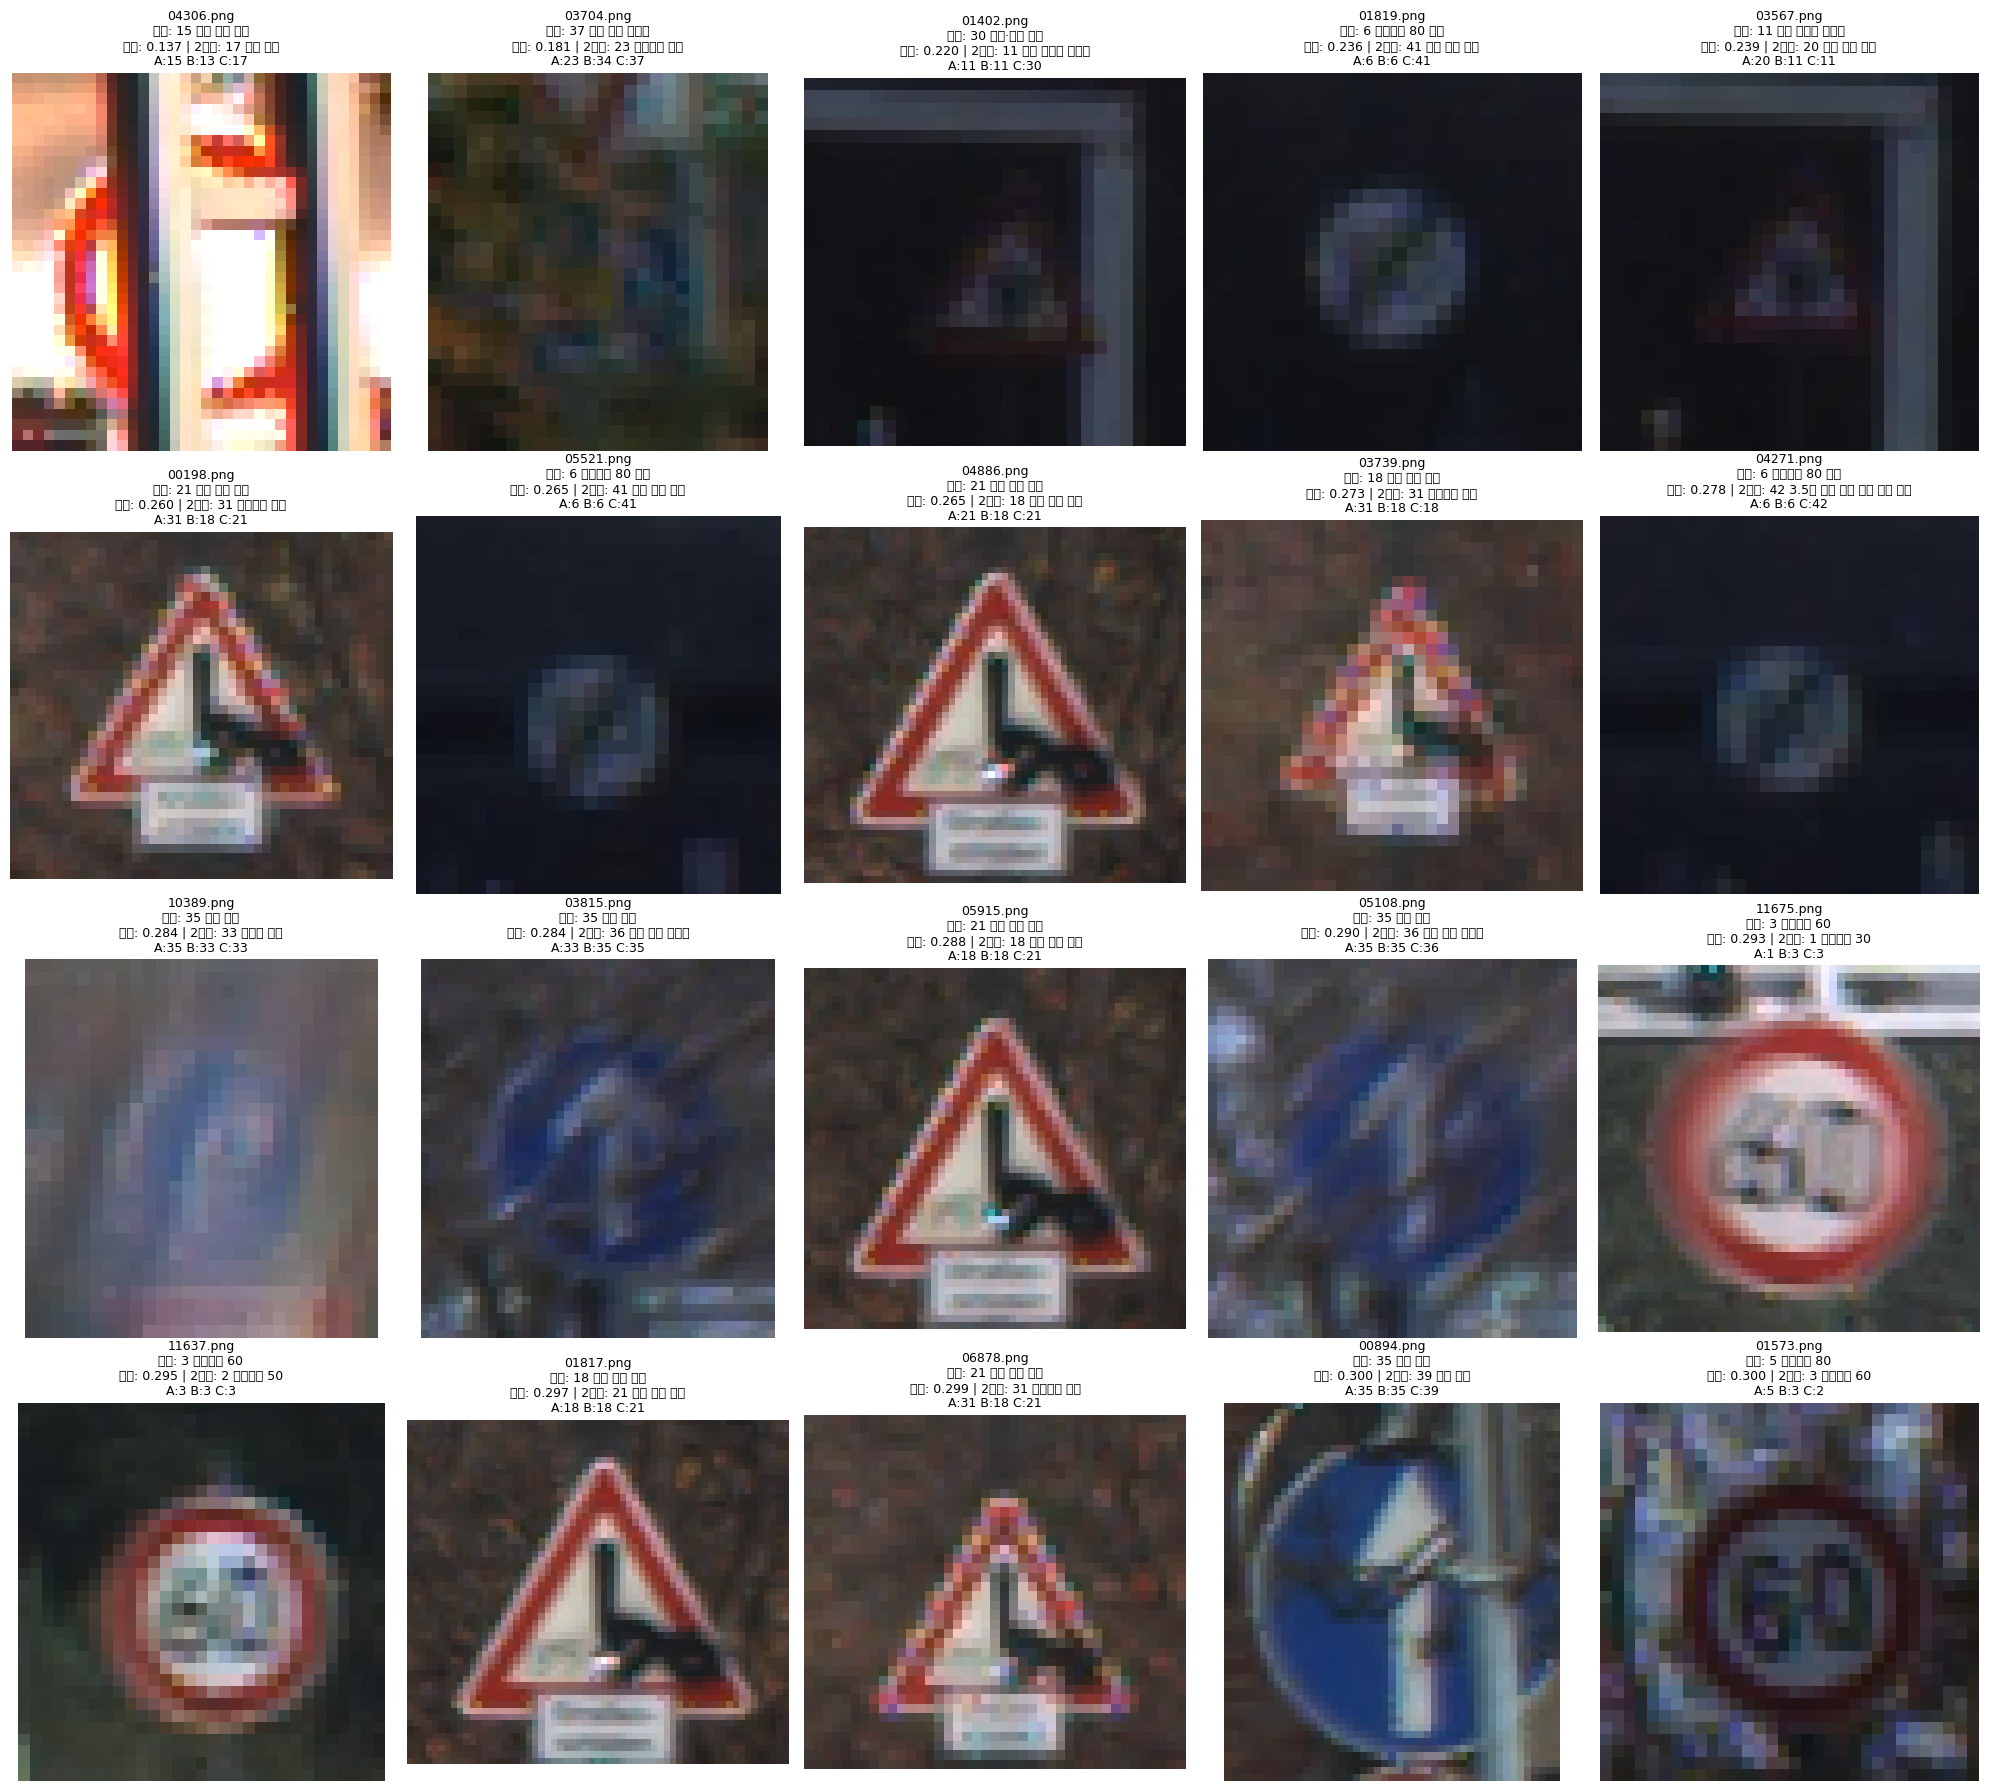

,filename,model_a_pred,model_a_sign_name,model_a_confidence,model_b_pred,model_b_sign_name,model_b_confidence,model_c_pred,model_c_sign_name,model_c_confidence,improved_pred,improved_sign_name,improved_confidence,improved_second_class,improved_second_sign_name,improved_second_confidence,prediction_changed_vs_old_ab,all_models_agree
0,04306.png,15,차량 통행 금지,0.271963,13,양보,0.278248,17,진입 금지,0.089499,15,차량 통행 금지,0.137170,17,진입 금지,0.073553,True,False
1,03704.png,23,미끄러운 도로,0.354638,34,좌회전 지시,0.267688,37,직진 또는 좌회전,0.241929,37,직진 또는 좌회전,0.180931,23,미끄러운 도로,0.171849,True,False
2,01402.png,11,다음 교차로 우선권,0.380757,11,다음 교차로 우선권,0.498259,30,빙판·눈길 주의,0.274934,30,빙판·눈길 주의,0.220477,11,다음 교차로 우선권,0.203111,True,False
3,01819.png,6,제한속도 80 해제,0.539259,6,제한속도 80 해제,0.306254,41,추월 금지 해제,0.170439,6,제한속도 80 해제,0.236296,41,추월 금지 해제,0.168913,False,False
4,03567.png,20,우측 위험 커브,0.472654,11,다음 교차로 우선권,0.783481,11,다음 교차로 우선권,0.245890,11,다음 교차로 우선권,0.238584,20,우측 위험 커브,0.224572,False,False
5,00198.png,31,야생동물 주의,0.570657,18,일반 위험 주의,0.327581,21,연속 위험 커브,0.349300,21,연속 위험 커브,0.260293,31,야생동물 주의,0.235235,True,False
6,05521.png,6,제한속도 80 해제,0.616105,6,제한속도 80 해제,0.300225,41,추월 금지 해제,0.190728,6,제한속도 80 해제,0.264614,41,추월 금지 해제,0.146924,False,False
7,04886.png,21,연속 위험 커브,0.229090,18,일반 위험 주의,0.326072,21,연속 위험 커브,0.284593,21,연속 위험 커브,0.265167,18,일반 위험 주의,0.238676,True,False
8,03739.png,31,야생동물 주의,0.480734,18,일반 위험 주의,0.233190,18,일반 위험 주의,0.406656,18,일반 위험 주의,0.273384,31,야생동물 주의,0.218902,True,False
9,04271.png,6,제한속도 80 해제,0.606668,6,제한속도 80 해제,0.269367,42,3.5톤 초과 차량 추월 금지 해제,0.151875,6,제한속도 80 해제,0.278288,42,3.5톤 초과 차량 추월 금지 해제,0.123298,False,False


In [18]:
show_test_predictions(
    start=0,
    n=20,
    sort_by='low_conf'
)

In [19]:
# 최종 앙상블 confidence가 낮은 순서로 20장 추출
low_conf_20 = (
    test_result
    .sort_values('improved_confidence', ascending=True)
    .head(20)
    .copy()
)

# 확인하기 편한 열만 선택
columns_to_save = [
    'original_row',
    'filename',

    'model_a_pred',
    'model_a_sign_name',
    'model_a_confidence',

    'model_b_pred',
    'model_b_sign_name',
    'model_b_confidence',

    'model_c_pred',
    'model_c_sign_name',
    'model_c_confidence',

    'improved_pred',
    'improved_sign_name',
    'improved_confidence',

    'improved_second_class',
    'improved_second_sign_name',
    'improved_second_confidence',
    'improved_margin',

    'prediction_changed_vs_old_ab',
    'all_models_agree',
]

# 실제 존재하는 열만 사용
columns_to_save = [
    col for col in columns_to_save
    if col in low_conf_20.columns
]

low_conf_20 = low_conf_20[columns_to_save]

# 사람이 직접 기록할 열 추가
low_conf_20['human_actual_class'] = ''
low_conf_20['human_actual_sign_name'] = ''
low_conf_20['human_judgment'] = ''
low_conf_20['difficulty_cause'] = ''
low_conf_20['notes'] = ''

# Drive의 improved_outputs 폴더에 저장
save_path = OUTPUT_DIR / 'test_lowest_confidence_20.csv'

low_conf_20.to_csv(
    save_path,
    index=False,
    encoding='utf-8-sig'
)

print('저장 완료:', save_path)
display(low_conf_20)

저장 완료: /content/drive/MyDrive/Data scientist/팀프로젝트/1주차/improved_outputs/test_lowest_confidence_20.csv


,original_row,filename,model_a_pred,model_a_sign_name,model_a_confidence,model_b_pred,model_b_sign_name,model_b_confidence,model_c_pred,model_c_sign_name,...,improved_second_sign_name,improved_second_confidence,improved_margin,prediction_changed_vs_old_ab,all_models_agree,human_actual_class,human_actual_sign_name,human_judgment,difficulty_cause,notes
4306,4306,04306.png,15,차량 통행 금지,0.271963,13,양보,0.278248,17,진입 금지,...,진입 금지,0.073553,0.063617,True,False,,,,,
3704,3704,03704.png,23,미끄러운 도로,0.354638,34,좌회전 지시,0.267688,37,직진 또는 좌회전,...,미끄러운 도로,0.171849,0.009082,True,False,,,,,
1402,1402,01402.png,11,다음 교차로 우선권,0.380757,11,다음 교차로 우선권,0.498259,30,빙판·눈길 주의,...,다음 교차로 우선권,0.203111,0.017366,True,False,,,,,
1819,1819,01819.png,6,제한속도 80 해제,0.539259,6,제한속도 80 해제,0.306254,41,추월 금지 해제,...,추월 금지 해제,0.168913,0.067383,False,False,,,,,
3567,3567,03567.png,20,우측 위험 커브,0.472654,11,다음 교차로 우선권,0.783481,11,다음 교차로 우선권,...,우측 위험 커브,0.224572,0.014012,False,False,,,,,
198,198,00198.png,31,야생동물 주의,0.570657,18,일반 위험 주의,0.327581,21,연속 위험 커브,...,야생동물 주의,0.235235,0.025058,True,False,,,,,
5479,5479,05521.png,6,제한속도 80 해제,0.616105,6,제한속도 80 해제,0.300225,41,추월 금지 해제,...,추월 금지 해제,0.146924,0.117690,False,False,,,,,
4881,4881,04886.png,21,연속 위험 커브,0.229090,18,일반 위험 주의,0.326072,21,연속 위험 커브,...,일반 위험 주의,0.238676,0.026492,True,False,,,,,
3739,3739,03739.png,31,야생동물 주의,0.480734,18,일반 위험 주의,0.233190,18,일반 위험 주의,...,야생동물 주의,0.218902,0.054483,True,False,,,,,
4271,4271,04271.png,6,제한속도 80 해제,0.606668,6,제한속도 80 해제,0.269367,42,3.5톤 초과 차량 추월 금지 해제,...,3.5톤 초과 차량 추월 금지 해제,0.123298,0.154989,False,False,,,,,
